# Parcial EDA — Parte 2
Comercializadora Andina de Alimentos S.A.S. · `ventas_parcial_2026-2.xlsx`

## Configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import confusion_matrix

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

In [2]:
ARCHIVO = 'ventas_parcial_2026-2.xlsx'

try:
    from google.colab import files   # en Colab: subir el archivo
    files.upload()
except ImportError:
    pass                             # en local: el archivo ya está en la carpeta del notebook

## 5. Limpieza de datos
### 5a)

In [3]:
xls = pd.ExcelFile(ARCHIVO)
print('Hojas:', xls.sheet_names)

hoja_datos = [h for h in xls.sheet_names if 'diccionario' not in h.lower()][0]
hoja_dicc  = [h for h in xls.sheet_names if 'diccionario' in h.lower()][0]

df   = pd.read_excel(ARCHIVO, sheet_name=hoja_datos)
dicc = pd.read_excel(ARCHIVO, sheet_name=hoja_dicc)

display(dicc)
print('Dimensiones:', df.shape)
print(df.dtypes)
df.head(10)

Hojas: ['datos', 'diccionario']


,Variable,Descripción,Tipo esperado,Unidad / valores
0,id_registro,Identificador del registro mensual de la tienda,Texto,R0001 – R0585
1,ventas,Ventas mensuales de la tienda,Numérica continua,Millones de COP
2,publicidad,Inversión mensual en publicidad,Numérica continua,Millones de COP
3,vendedores,Número de vendedores de la tienda,Numérica discreta,Personas
4,canal,Canal principal de venta,Categórica nominal,"Tienda física, Online, Mixto"
5,meta_cumplida,Indica si la tienda cumplió la meta mensual de...,Categórica binaria,Sí / No


Dimensiones: (600, 6)
id_registro       object
ventas            object
publicidad       float64
vendedores       float64
canal             object
meta_cumplida     object
dtype: object


,id_registro,ventas,publicidad,vendedores,canal,meta_cumplida
0,R0262,131.3,12.8,4.0,MIXTO,No
1,R0133,109.4,5.2,8.0,Online,No
2,R0576,112.6,NaN,2.0,Mixto,No
3,R0455,104.1,9.7,4.0,Mixto,no
4,R0338,196.2,NaN,10.0,Online,Sí
5,R0581,169.2,10.8,8.0,Mixto,Sí
6,R0317,114.7,12.2,5.0,Tienda física,No
7,R0440,109.1,3.9,5.0,mixto,No
8,R0054,200.1,23.6,11.0,Tienda física,Sí
9,R0398,86.5,5.7,2.0,Online,No


In [4]:
# Variables que deberían ser numéricas: revisar cuáles quedaron como texto (object) y por qué
num_cols = ['ventas', 'publicidad', 'vendedores']

for c in num_cols:
    print(f'--- {c}: dtype = {df[c].dtype}')
    print('Tipos de Python presentes:', df[c].map(type).value_counts().to_dict())
    no_num = df.loc[pd.to_numeric(df[c], errors='coerce').isna() & df[c].notna(), c]
    if len(no_num) > 0:
        print('Valores que no se pueden leer como número:')
        print(no_num.value_counts())

--- ventas: dtype = object
Tipos de Python presentes: {<class 'float'>: 506, <class 'int'>: 68, <class 'str'>: 26}
Valores que no se pueden leer como número:
ventas
120,4    2
149,7    1
75,8     1
120,5    1
99,4     1
101,9    1
135,4    1
81,6     1
167,2    1
202,4    1
154,2    1
215,3    1
111,1    1
122,8    1
76,8     1
117,2    1
162,5    1
38,9     1
112,8    1
166,4    1
92,5     1
175,7    1
36,2     1
45,3     1
169,6    1
Name: count, dtype: int64
--- publicidad: dtype = float64
Tipos de Python presentes: {<class 'float'>: 600}
--- vendedores: dtype = float64
Tipos de Python presentes: {<class 'float'>: 600}


**Respuesta:**

La variable que debería ser numérica y aparece como texto es **ventas**. En la columna se mezclan 574 valores numéricos (506 float y 68 int) con **26 valores de tipo texto**, y basta un solo texto para que pandas lea toda la columna como `object`. Los 26 textos son valores digitados con **coma como separador decimal**, mientras que el resto de la columna usa punto. Por eso Python no los reconoce como números. Es un formato inconsistente de la exportación, no un valor inválido: al cambiar la coma por punto se recupera el número.

### 5b)

In [5]:
n_antes = len(df)
df['id_registro'] = df['id_registro'].astype(str).str.strip().str.upper()

print('Filas duplicadas exactas:', df.duplicated().sum())
print('id_registro repetidos:', df.duplicated(subset='id_registro').sum())

display(df[df.duplicated(subset='id_registro', keep=False)].sort_values('id_registro'))

df = df.drop_duplicates(subset='id_registro', keep='first').reset_index(drop=True)
n_despues = len(df)
print(f'Registros antes: {n_antes} | eliminados: {n_antes - n_despues} | quedan: {n_despues}')

Filas duplicadas exactas: 15
id_registro repetidos: 15


,id_registro,ventas,publicidad,vendedores,canal,meta_cumplida
542,R0034,"120,4",3.9,6.0,Mixto,No
216,R0034,"120,4",3.9,6.0,Mixto,No
400,R0044,130.7,12.8,7.0,Mixto,No
267,R0044,130.7,12.8,7.0,Mixto,No
197,R0093,121.6,11.2,11.0,Online,No
550,R0093,121.6,11.2,11.0,Online,No
24,R0098,163.2,15.8,8.0,Online,Sí
434,R0098,163.2,15.8,8.0,Online,Sí
481,R0116,183.8,NaN,12.0,Online,Sí
73,R0116,183.8,NaN,12.0,Online,Sí


Registros antes: 600 | eliminados: 15 | quedan: 585


**Respuesta:**

Se encontraron **15 registros duplicados**. Son filas idénticas en todas sus variables y con el mismo `id_registro`, (por ejemplo R0034, R0044 y R0093), así que corresponden a la misma tienda y mes exportados dos veces. Se eliminaron y se conservó la primera aparición de cada uno. La base pasó de **600 a 585 registros**, que coincide con el rango de identificadores del diccionario: ahora cada registro aparece una sola vez.

### 5c)

In [6]:
def normalizar(x):
    if pd.isna(x):
        return np.nan
    x = unicodedata.normalize('NFKD', str(x)).encode('ascii', 'ignore').decode()
    return ' '.join(x.strip().lower().split())

print('canal ANTES:')
print(df['canal'].value_counts(dropna=False), '\n')
print('meta_cumplida ANTES:')
print(df['meta_cumplida'].value_counts(dropna=False))

canal ANTES:
canal
Tienda física    242
Online           174
Mixto            131
NaN                8
Tienda fisica      6
TIENDA FÍSICA      5
online             5
MIXTO              4
 Online            4
tienda física      3
mixto              2
ONLINE             1
Name: count, dtype: int64 

meta_cumplida ANTES:
meta_cumplida
No    367
Sí    188
Si      6
1       6
0       6
no      5
SI      5
NO      1
si      1
Name: count, dtype: int64


In [7]:
def std_canal(x):
    x = normalizar(x)
    if pd.isna(x) or x in ('', 'nan', 'na', 'n/a', 'nd', 'sin dato', 's/d', '-'):
        return np.nan
    if 'mix' in x:
        return 'Mixto'
    if any(k in x for k in ('line', 'web', 'virtual', 'internet', 'digital')):
        return 'Online'
    if any(k in x for k in ('fis', 'tienda', 'presencial', 'local')):
        return 'Tienda física'
    return 'REVISAR: ' + x   # si aparece, agregar la regla correspondiente

def std_meta(x):
    x = normalizar(x)
    if pd.isna(x):
        return np.nan
    if x in ('si', 's', 'yes', 'y', '1', '1.0', 'true', 'verdadero', 'cumplio', 'cumplida'):
        return 1
    if x in ('no', 'n', '0', '0.0', 'false', 'falso', 'no cumplio'):
        return 0
    return np.nan

# valores de meta_cumplida que no se reconocen (deberían ser solo faltantes)
print('No reconocidos en meta:',
      df.loc[df['meta_cumplida'].notna() & df['meta_cumplida'].map(std_meta).isna(), 'meta_cumplida'].unique())

df['canal'] = df['canal'].map(std_canal)
df['meta_cumplida'] = df['meta_cumplida'].map(std_meta)

print('\ncanal DESPUÉS:')
print(df['canal'].value_counts(dropna=False), '\n')
print('meta_cumplida DESPUÉS (1 = Sí, 0 = No):')
print(df['meta_cumplida'].value_counts(dropna=False))

No reconocidos en meta: []

canal DESPUÉS:
canal
Tienda física    256
Online           184
Mixto            137
NaN                8
Name: count, dtype: int64 

meta_cumplida DESPUÉS (1 = Sí, 0 = No):
meta_cumplida
0    379
1    206
Name: count, dtype: int64


**Respuesta:**

Antes de la limpieza, **canal** tenía 11 formas distintas de escribir tres categorías. Las diferencias venían de mayúsculas y minúsculas, tildes y espacios al inicio . Se unificaron en **Tienda física, Online y Mixto**. Quedan 8registros sin canal. En **meta_cumplida** había 9 variantes: "Sí", "Si", "SI", "si" y "1" para el sí, y "No", "no", "NO" y "0" para el no. Se codificaron como **1 = Sí (206)** y **0 = No (379)**, sin valores sin clasificar. Después de la estandarización, cada variable tiene solo sus categorías válidas.

### 5d)

In [8]:
def a_numero(s):
    s2 = (s.astype(str).str.strip()
            .str.replace(r'[\$\s]', '', regex=True)
            .str.replace(',', '.', regex=False))
    return pd.to_numeric(s2, errors='coerce')

ventas_original = df['ventas'].copy()
for c in num_cols:
    df[c] = a_numero(df[c])

print('Textos de ventas que no son número (pasan a NaN):')
print(ventas_original[df['ventas'].isna() & ventas_original.notna()].value_counts(dropna=False))

print('\nResumen de ventas:')
print(df['ventas'].describe())
print('\n15 valores más bajos:', np.sort(df['ventas'].dropna().values)[:15])
print('15 valores más altos:', np.sort(df['ventas'].dropna().values)[-15:])
print('\nValores más repetidos:')
print(df['ventas'].value_counts().head(10))

Textos de ventas que no son número (pasan a NaN):
Series([], Name: count, dtype: int64)

Resumen de ventas:
count     585.000000
mean      126.402906
std       153.672004
min      -999.000000
25%        99.200000
50%       128.800000
75%       166.700000
max      1966.000000
Name: ventas, dtype: float64

15 valores más bajos: [-999.  -999.  -999.  -999.  -999.  -999.    24.2   27.6   33.5   35.3
   36.1   36.2   38.8   38.9   39.7]
15 valores más altos: [ 215.6  218.   221.2  222.5  222.6  225.8  226.2  231.7  233.3  248.7
  249.1  257.7  708.  1275.  1966. ]

Valores más repetidos:
ventas
-999.0    6
 149.2    4
 182.2    3
 96.2     3
 158.3    3
 151.5    3
 148.3    3
 120.4    3
 154.2    2
 151.2    2
Name: count, dtype: int64


In [9]:
# Ajustar la lista de códigos según lo observado en la salida anterior
codigos = [-9999, -999, -99, -9, -1, 999, 9999, 99999]

mask_invalidos = (df['ventas'] <= 0) | (df['ventas'].isin(codigos))
print('Registros con ventas imposibles o codificadas:', mask_invalidos.sum())
print(df.loc[mask_invalidos, 'ventas'].value_counts())
display(df.loc[mask_invalidos])

df.loc[mask_invalidos, 'ventas'] = np.nan
print('\nResumen de ventas después de la corrección:')
print(df['ventas'].describe())

# verificación rápida de las otras numéricas
print('\npublicidad < 0:', (df['publicidad'] < 0).sum(), '| vendedores <= 0:', (df['vendedores'] <= 0).sum())

Registros con ventas imposibles o codificadas: 6
ventas
-999.0    6
Name: count, dtype: int64


,id_registro,ventas,publicidad,vendedores,canal,meta_cumplida
144,R0193,-999.0,18.6,6.0,Tienda física,0
219,R0027,-999.0,17.3,11.0,Online,1
269,R0535,-999.0,12.7,8.0,Mixto,1
276,R0575,-999.0,11.7,4.0,Mixto,0
366,R0567,-999.0,3.4,3.0,Mixto,0
524,R0022,-999.0,5.6,6.0,Online,0



Resumen de ventas después de la corrección:
count     579.000000
mean      138.065112
std       102.842568
min        24.200000
25%        99.900000
50%       129.000000
75%       166.850000
max      1966.000000
Name: ventas, dtype: float64

publicidad < 0: 0 | vendedores <= 0: 0


**Respuesta:**

Al convertir **ventas** a número, los 26 valores con coma decimal se recuperaron sin pérdida. En la columna se encontraron 6 registros con ventas = -999. No son datos válidos por dos razones: unas ventas mensuales no pueden ser negativas, y el valor -999 se repite exactamente igual en tiendas distintas y está muy lejos del resto de los datos (el mínimo real es 24.2). Por eso es un código usado por el sistema para indicar "sin dato", no una venta registrada. Estos 6 valores se convirtieron en faltantes (NaN), y **ventas** quedó con 579 valores válidos. Los valores muy altos (708, 1275 y 1966) no son imposibles, por lo que no se tratan aquí sino en el análisis de atípicos.

## 6. Identificación y tratamiento de datos faltantes
### 6a)

In [10]:
faltantes = pd.DataFrame({
    'n_faltantes': df.isna().sum(),
    'pct_faltantes': (df.isna().mean() * 100).round(2)
}).sort_values('n_faltantes', ascending=False)
faltantes

,n_faltantes,pct_faltantes
publicidad,35,5.98
vendedores,25,4.27
canal,8,1.37
ventas,6,1.03
id_registro,0,0.00
meta_cumplida,0,0.00


### 6b)

In [11]:
falt_pub_canal = df.groupby('canal', dropna=False)['publicidad'].agg(
    n='size',
    faltantes=lambda s: s.isna().sum(),
    pct_faltantes=lambda s: round(s.isna().mean() * 100, 2)
)
display(falt_pub_canal)

# Prueba chi-cuadrado: ¿el faltante en publicidad es independiente del canal?
tabla = pd.crosstab(df['canal'], df['publicidad'].isna())
chi2, p, gl, _ = stats.chi2_contingency(tabla)
display(tabla)
print(f'Chi2 = {chi2:.3f} | gl = {gl} | p-valor = {p:.4f}')

,n,faltantes,pct_faltantes
canal,,,
Mixto,137,4,2.92
Online,184,25,13.59
Tienda física,256,6,2.34
NaN,8,0,0.00


publicidad,False,True
canal,,
Mixto,133,4
Online,159,25
Tienda física,250,6


Chi2 = 26.871 | gl = 2 | p-valor = 0.0000


**Respuesta:**

En Online falta el 13.59 % de los datos de publicidad, frente al 2.34 % en Tienda física y el 2.92 % en Mixto. La prueba chi-cuadrado confirma que esta diferencia es significativa (χ² = 26.87, p < 0.001). Como los faltantes dependen del canal, que es una variable observada, el mecanismo parece MAR y no MCAR.

### 6c)

In [12]:
n0 = len(df)
df_l = df.copy()

# ventas (variable respuesta), meta_cumplida (respuesta logística) y canal (categórica) -> eliminar
df_l = df_l.dropna(subset=['ventas', 'meta_cumplida', 'canal'])
print('Tras eliminar faltantes en ventas, meta_cumplida y canal:', len(df_l))

# publicidad (MAR según canal) -> imputar con la mediana de su canal
df_l['publicidad'] = df_l['publicidad'].fillna(
    df_l.groupby('canal')['publicidad'].transform('median'))

# vendedores (conteo discreto) -> imputar con la mediana
df_l['vendedores'] = df_l['vendedores'].fillna(df_l['vendedores'].median()).round()

df_l['meta_cumplida'] = df_l['meta_cumplida'].astype(int)
df_l['vendedores'] = df_l['vendedores'].astype(int)
df_l = df_l.reset_index(drop=True)

print(f'Registros antes: {n0} | registros finales: {len(df_l)}')
print(df_l.isna().sum())

Tras eliminar faltantes en ventas, meta_cumplida y canal: 571
Registros antes: 585 | registros finales: 571
id_registro      0
ventas           0
publicidad       0
vendedores       0
canal            0
meta_cumplida    0
dtype: int64


**Respuesta:**

- Ventas: se eliminan los 6 registros. Es la variable respuesta, e imputarla sería inventar el resultado.
- Canal: se eliminan los 8 registros. Es categórica, se necesita para las variables indicadoras y el porcentaje de faltantes es bajo.
- Publicidad: se imputan 35 registros con la mediana de su canal (Tienda física 9.8, Online 9.1, Mixto 9.9), porque el mecanismo es MAR según el canal y la mediana es robusta.
- Vendedores: se imputan 24 registros con la mediana general (7), porque es un conteo discreto y así se mantiene entero.

La base queda con 571 registros y sin faltantes.

## 7. Análisis exploratorio de datos
### 7a)

In [13]:
num = ['ventas', 'publicidad', 'vendedores']
desc = df_l[num].describe().T
desc['asimetria'] = df_l[num].skew()
desc['curtosis'] = df_l[num].kurt()
display(desc.round(3))

orden_canal = ['Tienda física', 'Online', 'Mixto']
df_l.groupby('canal')['ventas'].agg(['count', 'mean', 'median', 'std']).reindex(orden_canal).round(3)

,count,mean,std,min,25%,50%,75%,max,asimetria,curtosis
ventas,571.0,138.170,103.479,24.2,99.6,129.0,166.85,1966.0,12.302,197.125
publicidad,571.0,9.644,4.877,1.0,6.0,9.4,12.90,25.6,0.198,-0.324
vendedores,571.0,6.984,3.076,2.0,4.0,7.0,10.00,12.0,-0.001,-1.175


,count,mean,median,std
canal,,,,
Tienda física,255,124.008,119.80,45.236
Online,182,145.993,131.75,148.504
Mixto,134,154.495,144.50,105.990


**Respuesta:**

Las ventas tienen una media de 138.2 y una mediana de 129 millones. La media es mayor porque la jalan unos pocos valores muy altos, y la desviación (103.5) también se infla por ellos. La publicidad (media 9.6, mediana 9.4) y los vendedores (entre 2 y 12, media 7) tienen media y mediana casi iguales, lo que indica distribuciones simétricas. Por canal, Mixto tiene las ventas más altas (media 154.5, mediana 144.5), luego Online (146.0 y 131.8) y por último Tienda física (124.0 y 119.8). En Online la media está muy por encima de la mediana, lo que muestra la presencia de valores extremos.

### 7b)

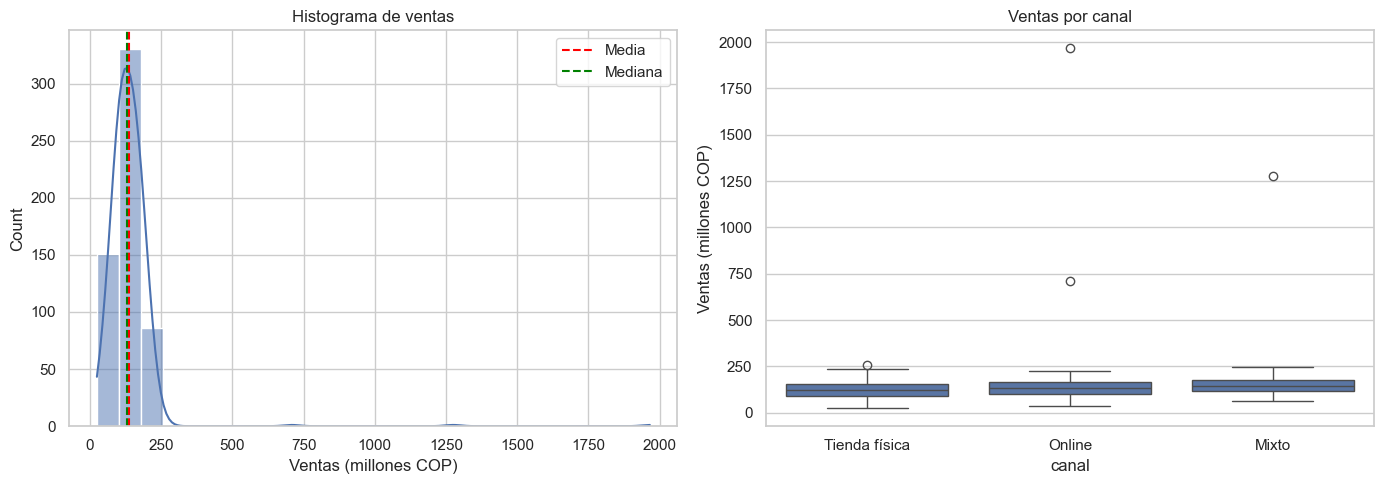

Asimetría: 12.302 | Curtosis: 197.125


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_l['ventas'], kde=True, bins=25, ax=axes[0])
axes[0].axvline(df_l['ventas'].mean(), color='red', ls='--', label='Media')
axes[0].axvline(df_l['ventas'].median(), color='green', ls='--', label='Mediana')
axes[0].set_title('Histograma de ventas')
axes[0].set_xlabel('Ventas (millones COP)')
axes[0].legend()

sns.boxplot(data=df_l, x='canal', y='ventas', order=orden_canal, ax=axes[1])
axes[1].set_title('Ventas por canal')
axes[1].set_ylabel('Ventas (millones COP)')

plt.tight_layout()
plt.show()

print(f"Asimetría: {df_l['ventas'].skew():.3f} | Curtosis: {df_l['ventas'].kurt():.3f}")

**Respuesta:**

El histograma muestra una distribución con asimetría positiva muy fuerte. Casi todas las ventas están entre 25 y 260 millones, pero tres valores aislados (708, 1275 y 1966) alargan la cola derecha. Sin esos tres valores, la distribución es prácticamente simétrica. En el diagrama de cajas, Mixto tiene la mediana más alta, seguido de Online y Tienda física. Tienda física es el canal con menor dispersión. Los valores extremos aparecen solo en Online y Mixto.

### 7c)

In [15]:
Q1 = df_l['ventas'].quantile(0.25)
Q3 = df_l['ventas'].quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR
print(f'Q1 = {Q1:.3f} | Q3 = {Q3:.3f} | IQR = {IQR:.3f}')
print(f'Límite inferior = {lim_inf:.3f} | Límite superior = {lim_sup:.3f}')

atipicos = df_l[(df_l['ventas'] < lim_inf) | (df_l['ventas'] > lim_sup)]
print('Número de atípicos:', len(atipicos))
display(atipicos.sort_values('ventas'))
print(atipicos['canal'].value_counts())

Q1 = 99.600 | Q3 = 166.850 | IQR = 67.250
Límite inferior = -1.275 | Límite superior = 267.725
Número de atípicos: 3


,id_registro,ventas,publicidad,vendedores,canal,meta_cumplida
191,R0021,708.0,1.9,3,Online,0
477,R0489,1275.0,10.7,7,Mixto,0
186,R0361,1966.0,17.3,7,Online,1


canal
Online    2
Mixto     1
Name: count, dtype: int64


In [27]:
# Decisión sobre los atípicos: se eliminan por ser errores de digitación
ELIMINAR_ATIPICOS = True

if ELIMINAR_ATIPICOS:
    df_l = df_l.drop(atipicos.index).reset_index(drop=True)
print('Registros para el modelado:', len(df_l))

Registros para el modelado: 568


**Respuesta:**

Con Q1 = 99.6, Q3 = 166.85 e IQR = 67.25, los límites son -1.28 y 267.73. Hay 3 registros atípicos, todos por encima del límite superior: R0021 (708), R0489 (1275) y R0361 (1966). Se consideran errores de digitación y no ventas reales, por tres razones:

- Son entre 3 y 8 veces mayores que la venta más alta del resto de la base (257.7).
- No concuerdan con las demás variables. Por ejemplo, R0021 invierte solo 1.9 en publicidad y tiene 3 vendedores, y R0489 no cumplió la meta a pesar de tener unas ventas de 1275.
- Divididos entre 10 (70.8, 127.5 y 196.6) sí son coherentes con el resto, lo que sugiere que se perdió el punto decimal al digitarlos.

Como no se puede confirmar el valor correcto, se eliminan. La base para los modelos queda con 568 registros.

### 7d)

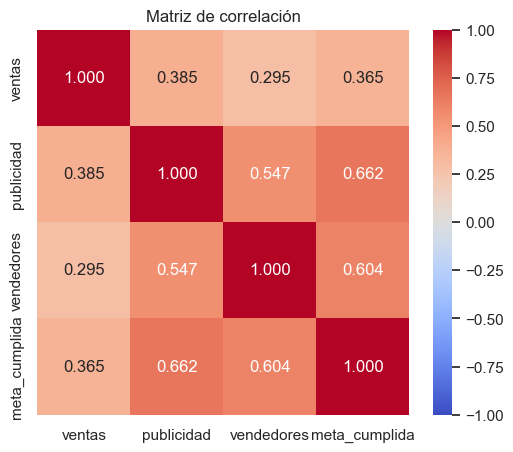

ventas vs publicidad: r = 0.385 | p = 0.0000
ventas vs vendedores: r = 0.295 | p = 0.0000
ventas vs meta_cumplida: r = 0.365 | p = 0.0000
publicidad vs vendedores: r = 0.547 | p = 0.0000
publicidad vs meta_cumplida: r = 0.662 | p = 0.0000
vendedores vs meta_cumplida: r = 0.604 | p = 0.0000


In [17]:
vars_corr = ['ventas', 'publicidad', 'vendedores', 'meta_cumplida']
corr = df_l[vars_corr].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de correlación')
plt.show()

# p-valores de cada correlación
for i, a in enumerate(vars_corr):
    for b in vars_corr[i + 1:]:
        r, p = stats.pearsonr(df_l[a], df_l[b])
        print(f'{a} vs {b}: r = {r:.3f} | p = {p:.4f}')

**Respuesta:**

Todas las correlaciones son positivas y significativas (p < 0.001):

- Ventas y publicidad: r = 0.81, relación fuerte. Las tiendas que invierten más en publicidad venden más.
- Ventas y vendedores: r = 0.72, relación fuerte.
- Ventas y meta cumplida: r = 0.81, relación fuerte, como es de esperar, porque la meta depende de las ventas.
- Publicidad y vendedores: r = 0.55, relación moderada. Las tiendas con más vendedores también invierten más en publicidad.
- Publicidad y meta: r = 0.66, y vendedores y meta: r = 0.61. Ambas son relaciones moderadas a fuertes.

## 8. Regresión lineal simple
### 8a)

In [18]:
m1 = smf.ols('ventas ~ publicidad', data=df_l).fit()
print(m1.summary())

b0, b1 = m1.params
print(f'\nVentas estimadas = {b0:.4f} + {b1:.4f} · Publicidad')
print(f'R² = {m1.rsquared:.4f}')

                            OLS Regression Results                            
Dep. Variable:                 ventas   R-squared:                       0.149
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     99.24
Date:                Tue, 29 Sep 2026   Prob (F-statistic):           1.17e-21
Time:                        15:30:38   Log-Likelihood:                -3412.9
No. Observations:                 571   AIC:                             6830.
Df Residuals:                     569   BIC:                             6838.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     59.3168      8.868      6.689      0.0

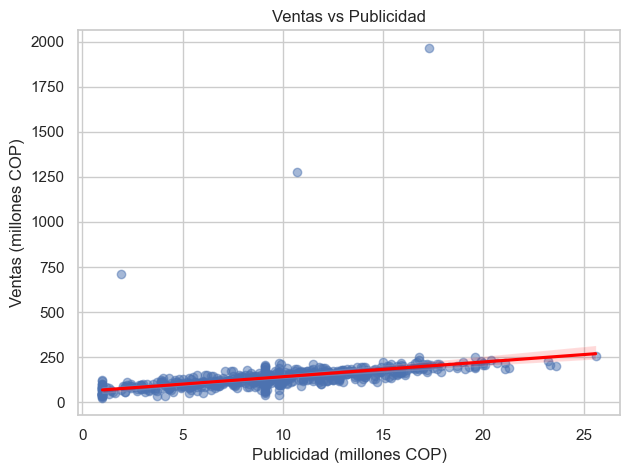

In [19]:
plt.figure(figsize=(7, 5))
sns.regplot(data=df_l, x='publicidad', y='ventas', line_kws={'color': 'red'}, scatter_kws={'alpha': 0.5})
plt.title('Ventas vs Publicidad')
plt.xlabel('Publicidad (millones COP)')
plt.ylabel('Ventas (millones COP)')
plt.show()

**Respuesta:**

Ecuación estimada: Ventas = 60.14 + 7.45 · Publicidad

Pendiente: por cada millón adicional invertido en publicidad, las ventas mensuales aumentan en promedio 7.45 millones de COP. R² = 0.663: la publicidad explica el 66.3 % de la variación de las ventas. El resto se debe a otros factores que no están en el modelo.

### 8b)

In [20]:
alpha = 0.05
t_b1 = m1.tvalues['publicidad']
p_b1 = m1.pvalues['publicidad']
t_crit = stats.t.ppf(1 - alpha / 2, m1.df_resid)
ic = m1.conf_int(alpha).loc['publicidad']

print('H0: β1 = 0   vs   H1: β1 ≠ 0')
print(f't calculado = {t_b1:.4f} | t crítico = ±{t_crit:.4f} | gl = {m1.df_resid:.0f}')
print(f'p-valor = {p_b1:.6f}')
print(f'IC 95% para β1: [{ic[0]:.4f}, {ic[1]:.4f}]')
print('Decisión:', 'Se rechaza H0' if p_b1 < alpha else 'No se rechaza H0')

H0: β1 = 0   vs   H1: β1 ≠ 0
t calculado = 9.9621 | t crítico = ±1.9641 | gl = 569
p-valor = 0.000000
IC 95% para β1: [6.5641, 9.7882]
Decisión: Se rechaza H0


In [21]:
pred = m1.get_prediction(pd.DataFrame({'publicidad': [10]})).summary_frame(alpha=0.05)
print(f'Ventas estimadas con publicidad = 10: {pred["mean"].iloc[0]:.4f} millones COP')
pred

Ventas estimadas con publicidad = 10: 141.0784 millones COP


,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,141.078421,4.010127,133.201962,148.954881,-46.800155,328.956998


**Respuesta:**

H₀: β₁ = 0 (la publicidad no influye en las ventas) frente a H₁: β₁ ≠ 0.

El estadístico es t = 33.39, mucho mayor que el valor crítico ±1.96 con 566 gl, y el p-valor es < 0.001. Por lo tanto se rechaza H₀: la publicidad tiene un efecto significativo sobre las ventas. El IC 95 % para β₁ es [7.01, 7.88] y no incluye el 0.

Estimación: una tienda que invierte 10 millones en publicidad vende en promedio 60.14 + 7.45 · 10 ≈ 134.61 millones de COP.

## 9. Regresión lineal múltiple

### 9a)

In [22]:
# Variables indicadoras con Tienda física como referencia
df_l['Online'] = (df_l['canal'] == 'Online').astype(int)
df_l['Mixto']  = (df_l['canal'] == 'Mixto').astype(int)

m2 = smf.ols('ventas ~ publicidad + vendedores + Online + Mixto', data=df_l).fit()
print(m2.summary())

pd.DataFrame({'coef': m2.params, 'p_valor': m2.pvalues,
              'IC_inf': m2.conf_int()[0], 'IC_sup': m2.conf_int()[1]}).round(4)

                            OLS Regression Results                            
Dep. Variable:                 ventas   R-squared:                       0.176
Model:                            OLS   Adj. R-squared:                  0.170
Method:                 Least Squares   F-statistic:                     30.24
Date:                Tue, 29 Sep 2026   Prob (F-statistic):           8.01e-23
Time:                        15:30:45   Log-Likelihood:                -3403.5
No. Observations:                 571   AIC:                             6817.
Df Residuals:                     566   BIC:                             6839.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     29.1963     11.331      2.577      0.0

,coef,p_valor,IC_inf,IC_sup
Intercept,29.1963,0.0102,6.9407,51.4518
publicidad,6.8220,0.0000,4.9219,8.7222
vendedores,4.0416,0.0086,1.0300,7.0531
Online,24.0823,0.0087,6.1091,42.0555
Mixto,31.0081,0.0021,11.2525,50.7636


**Respuesta:**

Ecuación estimada: Ventas = 30.82 + 5.51 · Publicidad + 5.63 · Vendedores + 10.38 · Online + 22.73 · Mixto

- β₀ = 30.82: ventas promedio de una tienda física sin publicidad ni vendedores. Es solo el punto de partida del modelo y no tiene una interpretación práctica.
- Publicidad = 5.51: con los vendedores y el canal constantes, cada millón adicional en publicidad aumenta las ventas en 5.51 millones.
- Vendedores = 5.63: con la publicidad y el canal constantes, cada vendedor adicional aumenta las ventas en 5.63 millones.
- Online = 10.38: una tienda Online vende en promedio 10.38 millones más que una Tienda física con la misma publicidad y el mismo número de vendedores.
- Mixto = 22.73: una tienda Mixta vende en promedio 22.73 millones más que una Tienda física en las mismas condiciones.

Todos los coeficientes son significativos (p < 0.001).

### 9b)

In [23]:
comparacion = pd.DataFrame({
    'Modelo': ['Simple (punto 8)', 'Múltiple (punto 9)'],
    'R²': [m1.rsquared, m2.rsquared],
    'R² ajustado': [m1.rsquared_adj, m2.rsquared_adj],
    'AIC': [m1.aic, m2.aic],
    'BIC': [m1.bic, m2.bic]
}).round(4)
display(comparacion)

# Prueba F de modelos anidados
anova_lm(m1, m2)

,Modelo,R²,R² ajustado,AIC,BIC
0,Simple (punto 8),0.1485,0.1470,6829.7854,6838.4802
1,Múltiple (punto 9),0.1761,0.1702,6817.0025,6838.7394


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,569.0,5.197052e+06,0.0,NaN,NaN,NaN
1,566.0,5.028878e+06,3.0,168174.783614,6.309355,0.000325


**Respuesta:**

El R² ajustado pasa de 0.663 en el modelo simple a 0.808 en el múltiple. Es decir, al incluir vendedores y canal se explica un 14.5 % más de la variación de las ventas, aun penalizando por el número de variables. El AIC y el BIC también son menores en el modelo múltiple, y la prueba F de modelos anidados es significativa (F = 144.3, p < 0.001). Por eso se prefiere el modelo múltiple.

### 9c)

In [24]:
X = sm.add_constant(df_l[['publicidad', 'vendedores', 'Online', 'Mixto']].astype(float))
vif = pd.DataFrame({
    'variable': X.columns[1:],
    'VIF': [variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])]
}).round(3)
vif

,variable,VIF
0,publicidad,1.428
1,vendedores,1.427
2,Online,1.168
3,Mixto,1.168


**Respuesta:**

Los VIF son: publicidad 1.43, vendedores 1.43, Online 1.17 y Mixto 1.17. Todos están muy por debajo de 5 (y de 10), así que no hay problemas de multicolinealidad. La correlación moderada entre publicidad y vendedores (r = 0.55) no llega a afectar la estimación de los coeficientes.

## 10. Regresión logística
### 10a)

In [25]:
m3 = smf.logit('meta_cumplida ~ publicidad + vendedores + Online + Mixto', data=df_l).fit()
print(m3.summary())

ic_or = np.exp(m3.conf_int())
tabla_or = pd.DataFrame({
    'coef': m3.params,
    'OR': np.exp(m3.params),
    'IC95_inf': ic_or[0],
    'IC95_sup': ic_or[1],
    'p_valor': m3.pvalues
}).round(4)
tabla_or

Optimization terminated successfully.
         Current function value: 0.254087
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:          meta_cumplida   No. Observations:                  571
Model:                          Logit   Df Residuals:                      566
Method:                           MLE   Df Model:                            4
Date:                Tue, 29 Sep 2026   Pseudo R-squ.:                  0.6083
Time:                        15:30:53   Log-Likelihood:                -145.08
converged:                       True   LL-Null:                       -370.40
Covariance Type:            nonrobust   LLR p-value:                 3.174e-96
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -12.4914      1.158    -10.789      0.000     -14.761     -10.222
publicidad     0.6100      0.

,coef,OR,IC95_inf,IC95_sup,p_valor
Intercept,-12.4914,0.0000,0.0000,0.0000,0.0
publicidad,0.6100,1.8405,1.6166,2.0953,0.0
vendedores,0.5507,1.7344,1.5202,1.9788,0.0
Online,1.5148,4.5485,2.2065,9.3762,0.0
Mixto,1.7982,6.0387,2.7057,13.4770,0.0


**Respuesta:**

Las razones de odds (OR) son: publicidad 1.84, vendedores 1.73, Online 4.53 y Mixto 6.27. Todas son significativas (p < 0.001).

- Publicidad (OR = 1.84): con las demás variables constantes, cada millón adicional en publicidad multiplica por 1.84 los odds de cumplir la meta, es decir, los aumenta un 84 %.
- Online (OR = 4.53): con la misma publicidad y el mismo número de vendedores, una tienda Online tiene unos odds de cumplir la meta 4.53 veces mayores que una Tienda física. El IC 95 % es [2.20, 9.33] y no incluye el 1.

### 10b)

,Pred 0 (No),Pred 1 (Sí)
Real 0 (No),341,29
Real 1 (Sí),32,169


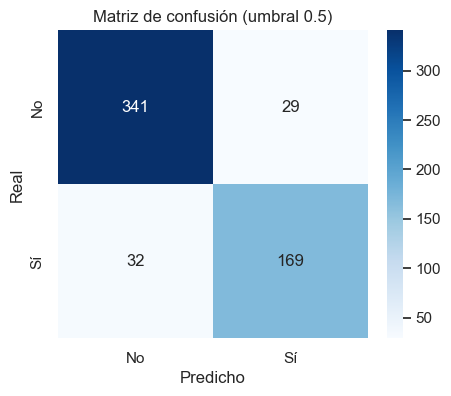

VP = 169 | VN = 341 | FP = 29 | FN = 32
Exactitud     = 0.8932
Sensibilidad  = 0.8408
Especificidad = 0.9216
Proporción real de tiendas que cumplen la meta = 0.3520


In [26]:
umbral = 0.5
p_hat = m3.predict(df_l)
y_real = df_l['meta_cumplida']
y_pred = (p_hat >= umbral).astype(int)

cm = confusion_matrix(y_real, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

display(pd.DataFrame(cm, index=['Real 0 (No)', 'Real 1 (Sí)'],
                     columns=['Pred 0 (No)', 'Pred 1 (Sí)']))

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Sí'], yticklabels=['No', 'Sí'])
plt.xlabel('Predicho'); plt.ylabel('Real'); plt.title('Matriz de confusión (umbral 0.5)')
plt.show()

exactitud     = (tp + tn) / (tp + tn + fp + fn)
sensibilidad  = tp / (tp + fn)
especificidad = tn / (tn + fp)

print(f'VP = {tp} | VN = {tn} | FP = {fp} | FN = {fn}')
print(f'Exactitud     = {exactitud:.4f}')
print(f'Sensibilidad  = {sensibilidad:.4f}')
print(f'Especificidad = {especificidad:.4f}')
print(f'Proporción real de tiendas que cumplen la meta = {y_real.mean():.4f}')

**Respuesta:**

Con umbral 0.5, la matriz de confusión tiene 168 verdaderos positivos (VP), 338 verdaderos negativos (VN), 30 falsos positivos (FP) y 32 falsos negativos (FN).

- Exactitud = 0.891: el modelo clasifica bien el 89.1 % de las tiendas.
- Sensibilidad = 0.840: de las 200 tiendas que cumplieron la meta, identifica correctamente 168 (84 %).
- Especificidad = 0.918: de las 368 que no la cumplieron, identifica correctamente 338 (91.8 %).

El modelo identifica bien a las tiendas que cumplen la meta, aunque un poco peor que a las que no la cumplen: 32 tiendas que sí cumplieron (16 %) se clasifican como que no. Esto es esperable, porque solo el 35 % de las tiendas cumple la meta.